<a href="https://colab.research.google.com/github/jasmine-0105/Linear-Regression/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
data = {
    "YearsExperience": [
        1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7,
        3.9, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0,
        6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5
    ],
    "Salary_Lakh": [
        3.93, 4.62, 3.77, 4.35, 3.99, 5.66, 6.02, 5.44, 6.44, 5.72,
        6.32, 5.58, 5.70, 5.71, 6.11, 6.79, 6.60, 8.30, 8.14, 9.39,
        9.17, 9.82, 10.14, 11.38, 10.94, 10.57, 11.69, 11.26, 12.23, 12.19
    ]
}

df = pd.DataFrame(data)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (30, 2)


,YearsExperience,Salary_Lakh
0,1.1,3.93
1,1.3,4.62
2,1.5,3.77
3,2.0,4.35
4,2.2,3.99


,YearsExperience,Salary_Lakh
0,1.1,3.93
1,1.3,4.62
2,1.5,3.77
3,2.0,4.35
4,2.2,3.99
5,2.9,5.66
6,3.0,6.02
7,3.2,5.44
8,3.2,6.44
9,3.7,5.72


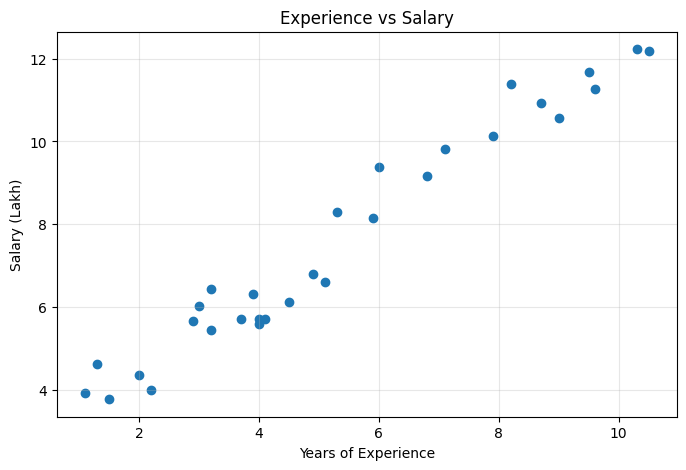

In [ ]:
display(df)

plt.figure(figsize=(8, 5))
plt.scatter(df["YearsExperience"], df["Salary_Lakh"])
plt.xlabel("Years of Experience")
plt.ylabel("Salary (Lakh)")
plt.title("Experience vs Salary")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
X = df[["YearsExperience"]]
y = df["Salary_Lakh"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30, 1)
y shape: (30,)


In [ ]:
# YOUR TASK: Set test_size to 0.25

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,   # Replace _____ with the required value
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records :", len(X_test))

Training records: 22
Testing records : 8


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [ ]:
# Generate predictions for the test set
y_pred = model.predict(X_test)

# YOUR TASK: Fill in the missing parts

intercept = model.intercept_
slope = model.coef_[0]

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MODEL RESULTS")
print("-" * 35)
print(f"Intercept : {intercept:.4f}")
print(f"Slope     : {slope:.4f}")
print(f"MAE       : {mae:.4f}")
print(f"RMSE      : {rmse:.4f}")
print(f"R²        : {r2:.4f}")

MODEL RESULTS
-----------------------------------
Intercept : 2.5453
Slope     : 0.9376
MAE       : 0.5027
RMSE      : 0.6205
R²        : 0.9352


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


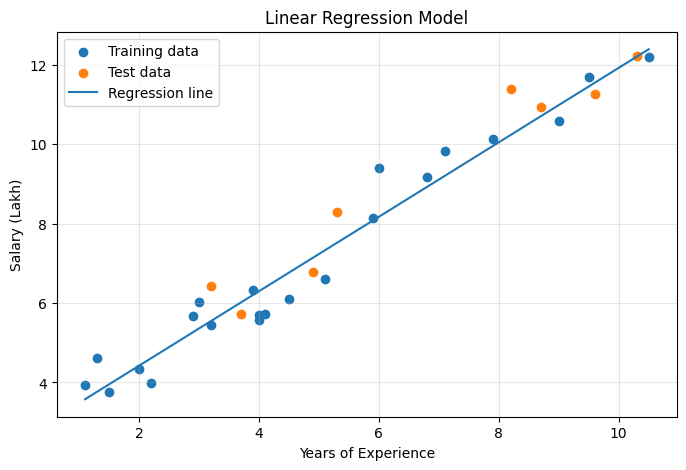

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train["YearsExperience"], y_train, label="Training data")
plt.scatter(X_test["YearsExperience"], y_test, label="Test data")

x_line = np.linspace(df["YearsExperience"].min(), df["YearsExperience"].max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)

plt.plot(x_line, y_line, label="Regression line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary (Lakh)")
plt.title("Linear Regression Model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# YOUR TASK: Enter the three experience values

new_experience = pd.DataFrame({
    "YearsExperience": [4.5,8,12]
})

predicted_salary = model.predict(new_experience)

prediction_table = new_experience.copy()
prediction_table["PredictedSalary_Lakh"] = predicted_salary

prediction_table

,YearsExperience,PredictedSalary_Lakh
0,4.5,6.764356
1,8.0,10.045832
2,12.0,13.796091


In [ ]:
results = pd.DataFrame({
    "Experience": X_test["YearsExperience"].values,
    "Actual_Salary": y_test.values,
    "Predicted_Salary": y_pred
})

# YOUR TASK
results["Residual"] = results["Actual_Salary"] - results["Predicted_Salary"]
results["Absolute_Residual"] = results["Residual"].abs()

results = results.sort_values("Experience").reset_index(drop=True)

results

,Experience,Actual_Salary,Predicted_Salary,Residual,Absolute_Residual
0,3.2,6.44,5.545522,0.894478,0.894478
1,3.7,5.72,6.014304,-0.294304,0.294304
2,4.9,6.79,7.139382,-0.349382,0.349382
3,5.3,8.30,7.514408,0.785592,0.785592
4,8.2,11.38,10.233345,1.146655,1.146655
5,8.7,10.94,10.702128,0.237872,0.237872
6,9.6,11.26,11.545936,-0.285936,0.285936
7,10.3,12.23,12.202231,0.027769,0.027769


In [ ]:
# Find the row index containing the largest absolute residual
largest_index = results["Absolute_Residual"].idxmax()

largest_residual_record = results.loc[largest_index]

print("Record with the largest absolute residual:")
display(largest_residual_record.to_frame().T)

Record with the largest absolute residual:


,Experience,Actual_Salary,Predicted_Salary,Residual,Absolute_Residual
4,8.2,11.38,10.233345,1.146655,1.146655


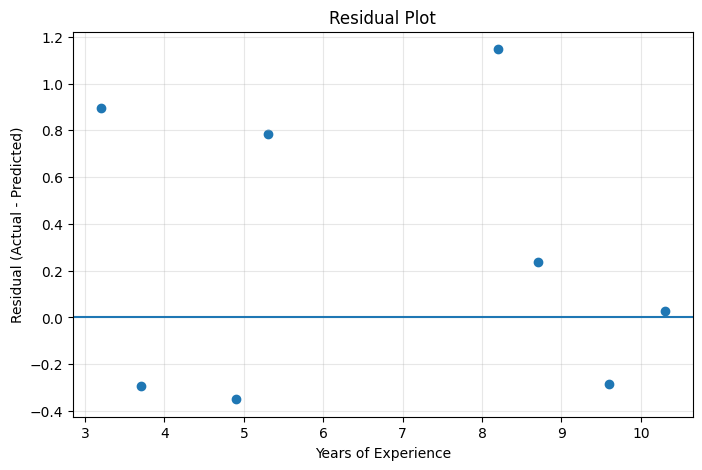

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(results["Experience"], results["Residual"])
plt.axhline(y=0)
plt.xlabel("Years of Experience")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.grid(alpha=0.3)
plt.show()